# Valuation Test Notebook

**Purpose:** Numeric oracle for the  `runDCF()` implementation.

This notebook:
- Tests each DCF formula independently
- Reproduces the Week 0 hand-worked reference case
- Tests the terminal-growth guardrail
- Tests a zero-growth edge case
- Builds a WACC × terminal-growth sensitivity grid
- Runs automated sanity/reference checks

## 1. Imports

In [1]:
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

## 2. Reference Case Inputs

In [2]:
FCF_0 = 100       # $ million
g = 0.08          # 8% annual FCF growth
N = 5             # Explicit forecast period
r = 0.10          # 10% WACC
g_T = 0.03        # 3% terminal growth
net_debt = 50      # $ million
shares = 100       # million shares

print("Reference Case")
print(f"FCF₀ = ${FCF_0}m")
print(f"Growth = {g:.1%}")
print(f"Years = {N}")
print(f"WACC = {r:.1%}")
print(f"Terminal g = {g_T:.1%}")
print(f"Net Debt = ${net_debt}m")
print(f"Shares = {shares}m")


Reference Case
FCF₀ = $100m
Growth = 8.0%
Years = 5
WACC = 10.0%
Terminal g = 3.0%
Net Debt = $50m
Shares = 100m


## 3. Formula 1 - FCF Projection

\[
FCF_t = FCF_0(1+g)^t
\]

In [3]:
fcf = []

for t in range(1, N + 1):
    FCF_t = FCF_0 * (1 + g) ** t
    fcf.append(FCF_t)

for t, value in enumerate(fcf, start=1):
    print(f"Year {t}: FCF = ${value:.2f}m")

Year 1: FCF = $108.00m
Year 2: FCF = $116.64m
Year 3: FCF = $125.97m
Year 4: FCF = $136.05m
Year 5: FCF = $146.93m


## 4. Formula 2 - Discount Factors

\[
DF_t = \frac{1}{(1+r)^t}
\]

In [4]:
discount_factors = []

for t in range(1, N + 1):
    DF_t = 1 / (1 + r) ** t
    discount_factors.append(DF_t)

for t, value in enumerate(discount_factors, start=1):
    print(f"Year {t}: DF = {value:.4f}")

Year 1: DF = 0.9091
Year 2: DF = 0.8264
Year 3: DF = 0.7513
Year 4: DF = 0.6830
Year 5: DF = 0.6209


## 5. Formula 3 - Present Value of Each FCF

\[
PV_t = FCF_t \times DF_t
\]

In [5]:
pv_fcf = []

for t in range(N):
    PV_t = fcf[t] * discount_factors[t]
    pv_fcf.append(PV_t)

for t, value in enumerate(pv_fcf, start=1):
    print(f"Year {t}: PV = ${value:.2f}m")

Year 1: PV = $98.18m
Year 2: PV = $96.40m
Year 3: PV = $94.64m
Year 4: PV = $92.92m
Year 5: PV = $91.23m


## 6. Formula 4 - Explicit Period PV

\[
PV_{explicit} = \sum_{t=1}^{N}\frac{FCF_t}{(1+r)^t}
\]

In [6]:
PV_explicit = sum(pv_fcf)

print(f"PV Explicit = ${PV_explicit:.2f}m")

PV Explicit = $473.38m


## 7. Formula 5 - Terminal Value

\[
TV_N = \frac{FCF_N(1+g_T)}{r-g_T}
\]

Guardrail: **terminal growth must be less than WACC.**

In [7]:
FCF_N = fcf[-1]

if r <= g_T:
    raise ValueError("Terminal growth must be less than WACC.")

TV = FCF_N * (1 + g_T) / (r - g_T)

print(f"FCF_N = ${FCF_N:.2f}m")
print(f"Terminal Value = ${TV:.2f}m")

FCF_N = $146.93m
Terminal Value = $2162.01m


## 8. Formula 6 - Present Value of Terminal Value

\[
PV_{TV} = \frac{TV_N}{(1+r)^N}
\]

In [8]:
PV_TV = TV / (1 + r) ** N

print(f"PV Terminal Value = ${PV_TV:.2f}m")

PV Terminal Value = $1342.44m


## 9. Formula 7 - Enterprise Value

\[
EV = PV_{explicit} + PV_{TV}
\]

In [9]:
EV = PV_explicit + PV_TV

print(f"Enterprise Value = ${EV:.2f}m")

Enterprise Value = $1815.82m


## 10. Formula 8 - Equity Value

\[
E = EV - NetDebt
\]

In [10]:
equity_value = EV - net_debt

print(f"Equity Value = ${equity_value:.2f}m")

Equity Value = $1765.82m


## 11. Formula 9 - Intrinsic Value per Share

\[
Value/share = \frac{E}{Shares}
\]

In [11]:
value_per_share = equity_value / shares

print(f"Intrinsic Value / Share = ${value_per_share:.2f}")

Intrinsic Value / Share = $17.66


## 12. Complete DCF Calculation - Prototype of `runDCF()`

In [12]:
FCF_0 = 100
g = 0.08
N = 5
r = 0.10
g_T = 0.03
net_debt = 50
shares = 100

fcf = [
    FCF_0 * (1 + g) ** t
    for t in range(1, N + 1)
]

pv_fcf = [
    FCF_t / (1 + r) ** t
    for t, FCF_t in enumerate(fcf, start=1)
]

PV_explicit = sum(pv_fcf)

if r <= g_T:
    raise ValueError("Terminal growth must be less than WACC.")

TV = fcf[-1] * (1 + g_T) / (r - g_T)

PV_TV = TV / (1 + r) ** N

EV = PV_explicit + PV_TV

equity_value = EV - net_debt

value_per_share = equity_value / shares

print("DCF VALUATION")
print(f"PV Explicit : ${PV_explicit:.2f}m")
print(f"Terminal Value : ${TV:.2f}m")
print(f"PV Terminal Value : ${PV_TV:.2f}m")
print(f"Enterprise Value : ${EV:.2f}m")
print(f"Equity Value : ${equity_value:.2f}m")
print(f"Value / Share : ${value_per_share:.2f}")

DCF VALUATION
PV Explicit : $473.38m
Terminal Value : $2162.01m
PV Terminal Value : $1342.44m
Enterprise Value : $1815.82m
Equity Value : $1765.82m
Value / Share : $17.66


## 13. Forecast Table

In [13]:
forecast = pd.DataFrame({
    "Year": range(1, N + 1),
    "FCF ($m)": fcf,
    "Discount Factor": discount_factors,
    "PV of FCF ($m)": pv_fcf
})
forecast

,Year,FCF ($m),Discount Factor,PV of FCF ($m)
0,1,108.000000,0.909091,98.181818
1,2,116.640000,0.826446,96.396694
2,3,125.971200,0.751315,94.644027
3,4,136.048896,0.683013,92.923227
4,5,146.932808,0.620921,91.233713


## 14. Automated Reference Test

The hand-worked values are rounded, so the tests use a small tolerance.

In [14]:
expected_PV_explicit = 473.38
expected_TV = 2162.01
expected_PV_TV = 1342.44
expected_EV = 1815.82
expected_equity = 1765.82
expected_value_per_share = 17.66

tolerance = 0.05

assert abs(PV_explicit - expected_PV_explicit) < tolerance
assert abs(TV - expected_TV) < tolerance
assert abs(PV_TV - expected_PV_TV) < tolerance
assert abs(EV - expected_EV) < tolerance
assert abs(equity_value - expected_equity) < tolerance
assert abs(value_per_share - expected_value_per_share) < tolerance

print("Reference case passed all tests.")

Reference case passed all tests.


## 15. Hard Guardrail Test - Terminal Growth ≥ WACC

In [15]:
test_r = 0.10
test_g_T = 0.10

try:
    if test_r <= test_g_T:
        raise ValueError("Terminal growth must be less than WACC.")

    print("ERROR: Invalid inputs were accepted.")

except ValueError as e:
    print(f"Guardrail triggered: {e}")

Guardrail triggered: Terminal growth must be less than WACC.


## 16. Edge Case - Zero Growth

In [16]:
FCF_0_test = 100
g_test = 0.0
N_test = 5
r_test = 0.10
g_T_test = 0.03

fcf_test = [
    FCF_0_test * (1 + g_test) ** t
    for t in range(1, N_test + 1)
]

pv_test = [
    FCF_t / (1 + r_test) ** t
    for t, FCF_t in enumerate(fcf_test, start=1)
]

PV_explicit_test = sum(pv_test)

TV_test = (
    fcf_test[-1] * (1 + g_T_test)
    / (r_test - g_T_test)
)

PV_TV_test = TV_test / (1 + r_test) ** N_test

EV_test = PV_explicit_test + PV_TV_test

print(f"Projected FCFs: {fcf_test}")
print(f"PV Explicit: ${PV_explicit_test:.2f}m")
print(f"Terminal Value: ${TV_test:.2f}m")
print(f"PV Terminal Value: ${PV_TV_test:.2f}m")
print(f"Enterprise Value: ${EV_test:.2f}m")


Projected FCFs: [100.0, 100.0, 100.0, 100.0, 100.0]
PV Explicit: $379.08m
Terminal Value: $1471.43m
PV Terminal Value: $913.64m
Enterprise Value: $1292.72m


## 17. Sensitivity - WACC × Terminal Growth

In [17]:
wacc_values = np.array([0.08, 0.09, 0.10, 0.11, 0.12])
terminal_growth_values = np.array([0.01, 0.02, 0.03, 0.04, 0.05])

sensitivity = pd.DataFrame(
    index=[f"{g:.0%}" for g in terminal_growth_values],
    columns=[f"{r:.0%}" for r in wacc_values],
    dtype=float
)

for g_T_value in terminal_growth_values:
    for r_value in wacc_values:

        if r_value <= g_T_value:
            sensitivity.loc[f"{g_T_value:.0%}", f"{r_value:.0%}"] = np.nan
            continue

        TV_value = FCF_N * (1 + g_T_value) / (r_value - g_T_value)
        PV_TV_value = TV_value / (1 + r_value) ** N

        EV_value = PV_explicit + PV_TV_value
        equity_value_value = EV_value - net_debt
        share_value = equity_value_value / shares

        sensitivity.loc[
            f"{g_T_value:.0%}",
            f"{r_value:.0%}"
        ] = share_value

sensitivity

,8%,9%,10%,11%,12%
1%,18.662366,16.290196,14.472245,13.040739,11.889009
2%,21.233795,18.148962,15.866093,14.116175,12.737904
3%,24.833795,20.627317,17.658184,15.460469,13.775443
4%,30.233795,24.097013,20.047638,17.188847,15.072366
5%,39.233795,29.301559,23.392875,19.493352,16.739838


## 18. Sensitivity Plot

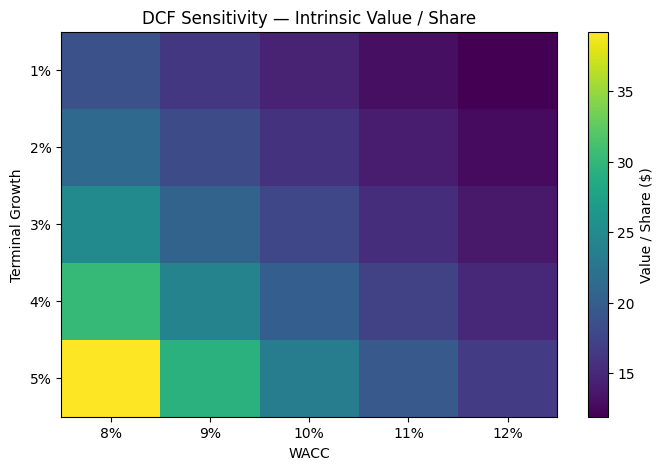

In [18]:
plt.figure(figsize=(8, 5))

plt.imshow(sensitivity.values, aspect="auto")

plt.xticks(
    range(len(sensitivity.columns)),
    sensitivity.columns
)

plt.yticks(
    range(len(sensitivity.index)),
    sensitivity.index
)

plt.xlabel("WACC")
plt.ylabel("Terminal Growth")
plt.title("DCF Sensitivity — Intrinsic Value / Share")

plt.colorbar(label="Value / Share ($)")

plt.show()

## 19. Final Sanity Checks

In [19]:
assert FCF_0 > 0
assert N > 0
assert r > g_T
assert shares > 0

assert all(x > 0 for x in fcf)
assert PV_explicit > 0
assert TV > 0
assert PV_TV > 0
assert EV > 0
assert equity_value > 0
assert value_per_share > 0

print("All sanity checks passed.")

All sanity checks passed.


## Expected Reference Result

Using full-precision calculations, the reference case should produce approximately:

| Metric | Expected |
|---|---:|
| PV Explicit | $473.40m |
| Terminal Value | $2,162.01m |
| PV Terminal Value | $1,342.46m |
| Enterprise Value | $1,815.86m |
| Equity Value | $1,765.86m |
| Intrinsic Value / Share | **$17.66** |

Small differences from the Week 0 hand-worked table are due to rounding intermediate discount factors.
